In [7]:
import numpy as np
import astropy.io.fits as fits
import os
import yaml
from astropy.table import Table
import matplotlib.pyplot as plt
%matplotlib inline

# Replace Image With Substructure-deprojected Image

In this notebook, we replace the broadband image extension in image and grism cutouts, to the cleaned version where substructures of galaxies are removed. 

In [12]:
root_dir = "/xdisk/timeifler/jiachuanxu/jwst/fresco_gds"
# root_dir = "/xdisk/timeifler/jiachuanxu/jwst/congress_fresco_gdn"
bd_decompose_dir = os.path.join(root_dir, "bulge_disk_2D/ID%d")
field = "GDS"
image_cutout_dir = os.path.join(root_dir, "data_compile")
catalog_fn = os.path.join("/xdisk/timeifler/jiachuanxu/jwst/fengwu_catalog", 
            "v2_gds_fresco_line_list_low-ground-z_Pa_Br_jades_dr5_blended.fits"
            #"v2_gdn_merged_line_list_low-ground-z_Pa_Br_jades_dr5_blended.fits"
            )

# load catalog
catalog = Table().read(catalog_fn, format="fits")

In [13]:
for i in range(len(catalog)):
    # get the ID of the galaxy
    galaxy_id = catalog[i]["ID"]
    # get the path to the bulge-disk decomposition fits file
    bd_decompose_fn = os.path.join(bd_decompose_dir % galaxy_id, 
                                   "substruct_deprojected.npy")
    # get the path to the image cutout fits file
    image_cutout_fn = os.path.join(image_cutout_dir, 
                                   f"data_compile_{field}_ID{galaxy_id}.fits")
    replaced_fn = os.path.join(image_cutout_dir, 
                               f"data_compile_{field}_ID{galaxy_id}_substructdeproj.fits")
    # get the B+D decomposition summary info
    bd_summary_fn = os.path.join(bd_decompose_dir % galaxy_id,
                                 "ID_%d_2D_summary.yaml"%galaxy_id)

    # check if both files exist
    if not os.path.exists(bd_decompose_fn):
        print(f"Bulge-disk decomposition file does not exist for galaxy ID {galaxy_id}. Skipping.")
        continue
    if not os.path.exists(image_cutout_fn):
        print(f"Image cutout file does not exist for galaxy ID {galaxy_id}. Skipping.")
        continue
    if not os.path.exists(bd_summary_fn):
        print(f"Bulge-disk decomposition summary file does not exist for galaxy ID {galaxy_id}. Skipping.")
        continue
    
    # load the bulge-disk decomposition data & summary info
    bd_data = np.load(bd_decompose_fn)
    with open(bd_summary_fn, 'r') as f:
        bd_summary = yaml.safe_load(f)

    # load the image cutout data
    image_data = fits.open(image_cutout_fn)
    image_data["F444WIMG"].data = bd_data

    # add B+D info into primary header
    image_data[0].header["BD_TYPE"] = bd_summary["model_type"]
    image_data[0].header["BTRATIO"] = bd_summary["bt_ratio_fit_mask"]
    image_data[0].header["DISK_RW"] = bd_summary["is_runaway_disk"]
    image_data[0].header["AGNLIKE"] = bd_summary["is_agn_like"]
    for k,v in bd_summary["bestfit_params"].items():
        image_data[0].header[f"BD_{k.upper()}"] = v

    
    # replace the image data with the bulge-disk decomposition data
    image_data.writeto(replaced_fn, overwrite=True)
    
    print(f"Replaced image data with bulge-disk decomposition for galaxy ID {galaxy_id}.")

Replaced image data with bulge-disk decomposition for galaxy ID 74131.
Replaced image data with bulge-disk decomposition for galaxy ID 76682.
Replaced image data with bulge-disk decomposition for galaxy ID 85484.
Replaced image data with bulge-disk decomposition for galaxy ID 94908.
Replaced image data with bulge-disk decomposition for galaxy ID 95680.
Replaced image data with bulge-disk decomposition for galaxy ID 99892.
Replaced image data with bulge-disk decomposition for galaxy ID 105191.
Replaced image data with bulge-disk decomposition for galaxy ID 111621.
Replaced image data with bulge-disk decomposition for galaxy ID 113418.
Replaced image data with bulge-disk decomposition for galaxy ID 113730.
Replaced image data with bulge-disk decomposition for galaxy ID 114914.
Replaced image data with bulge-disk decomposition for galaxy ID 114926.
Replaced image data with bulge-disk decomposition for galaxy ID 120217.
Replaced image data with bulge-disk decomposition for galaxy ID 120414

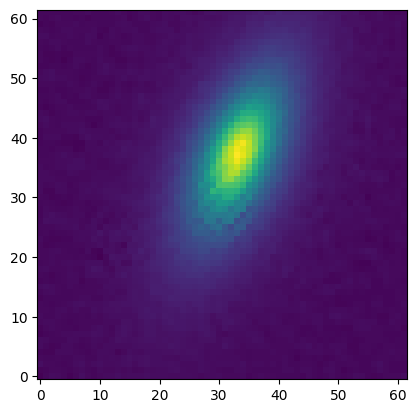

In [14]:
### Examine if replace is successful
test_id = 180912
test_img = fits.open(
    os.path.join(image_cutout_dir, 
                 f"data_compile_{field}_ID{test_id}_substructdeproj.fits")
)
plt.imshow(test_img["F444WIMG"].data, origin="lower")
plt.show()

In [15]:
test_img[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
RA0     =            53.062935 / Reference position RA in direct image          
DEC0    =           -27.858614 / Reference position DEC in direct image         
N_COADD =                    8 / Total coadded grism frames                     
N_R     =                    8 / Number of grism-R frames                       
N_C     =                    0 / Number of grism-C frames                       
FILTER  = 'F444W   '           / Photometric filter                             
COMMENTS= 'Below are columns from the input source catalog:'                    
ID      =               180912                                                  
RA      =            53.0629